#### Prédiction de la Consommation par tete et le Calcul des Taux de Pauvreté fullyConv_sans_augm_couche_nongelee_batch_16

Ce script est conçu pour effectuer une analyse approfondie des données afin de prédire la consommation des ménages (log_pcexp) et d'estimer les taux de pauvreté. Le processus est divisé en plusieurs étapes :

- Préparation des données : Les données sont lues depuis un fichier CSV contenant des milliers de variables explicatives (feature_0 à feature_4095) et des variables contextuelles. Ces données sont divisées en deux ensembles : un ensemble d’entraînement (60%) utilisé pour construire les modèles, et un ensemble de test (40%) réservé à leur évaluation.

- Standardisation et réduction dimensionnelle : Pour homogénéiser l’échelle des variables, une standardisation est appliquée à l'aide de StandardScaler. Ensuite, une réduction dimensionnelle est effectuée avec la méthode PCA (Principal Component Analysis) pour conserver 95% de la variabilité des données tout en simplifiant leur structure. Cette étape est cruciale pour limiter la surdimensionnalité dans certains cas de modélisation.

- Modélisation prédictive : Trois approches sont utilisées pour prédire log_pcexp :

  - OLS après PCA : Une régression linéaire (OLS) est appliquée sur les composantes principales issues de la PCA.
  - Ridge après PCA : Une régression Ridge est réalisée après PCA, avec une recherche d’hyperparamètre α optimal via une validation croisée.
  - Ridge sans PCA : Une régression Ridge est exécutée sur toutes les variables standardisées sans réduction dimensionnelle, en optimisant également α. Chaque modèle est évalué à l’aide du score R^2 sur les ensembles d’entraînement et de test pour mesurer la qualité des prédictions.

- Sauvegarde des résultats :

  - Les modèles entraînés sont sauvegardés sous forme de fichiers .pkl.
  - Des graphiques illustrant la corrélation entre les valeurs réelles et prédites pour chaque modèle sont générés et sauvegardés dans un répertoire dédié.
  - Les prédictions issues des trois modèles (OLS PCA, Ridge PCA, Ridge sans PCA) sont ajoutées au DataFrame de test et enregistrées dans un fichier CSV enrichi.
- Calcul des taux de pauvreté :

  - Un seuil de pauvreté est défini à log(345520). Une variable binaire est créée pour indiquer si un ménage est classé comme pauvre (1) ou non (0), basée sur la consommation réelle (log_pcexp) ou prédite.
  - Le taux de pauvreté réel est calculé en pondérant les observations par les poids (hhweight) et les tailles (hhsize) des ménages.
  - Les taux de pauvreté prédits sont estimés pour chaque modèle (OLS PCA, Ridge PCA, Ridge sans PCA) en utilisant les mêmes pondérations. Les résultats sont imprimés pour comparaison.
  - Fichier final : Le fichier final, contenant les prédictions, les variables de pauvreté, et les taux calculés, est sauvegardé pour un usage ultérieur.

Ce script permet une analyse complète, de la préparation initiale des données à l’interprétation des résultats, en automatisant chaque étape clé. Il est particulièrement utile pour des applications en économétrie et en évaluation des politiques publiques, fournissant des modèles prédictifs robustes et des indicateurs clairs pour la prise de décision.

Nombre de composantes principales expliquant 90% de la variabilité : 118
R² (OLS PCA) - Train: 0.1729, Test: 0.1345


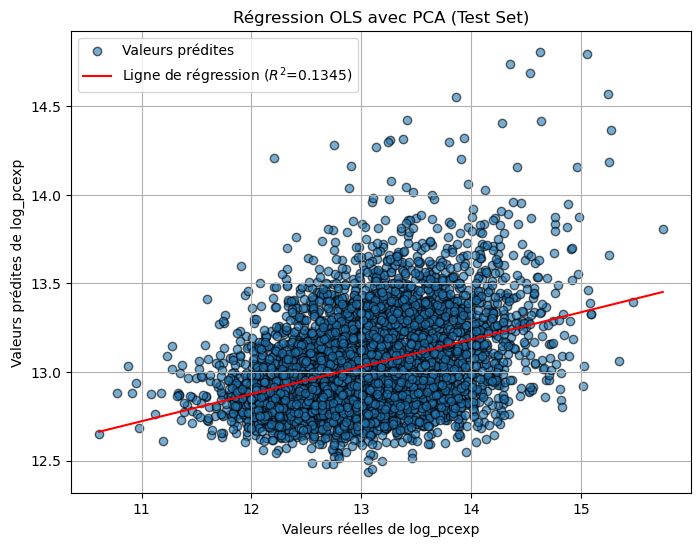

R² (Ridge PCA) - Train: 0.1729, Test: 0.1357, Alpha: 1000.0


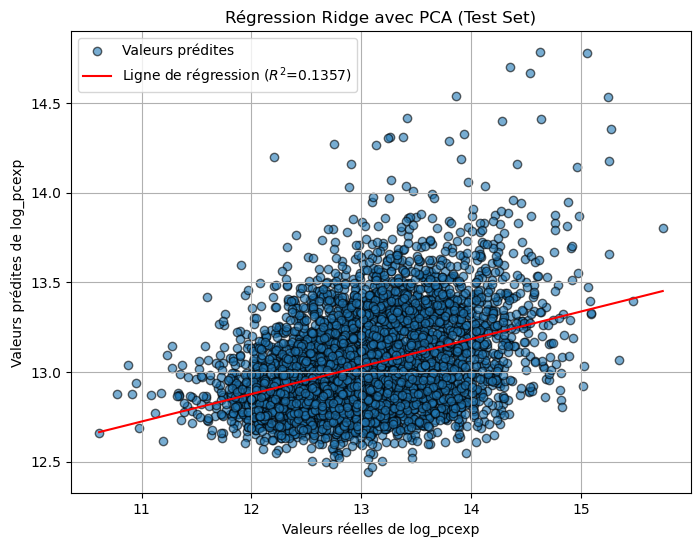

R² (Ridge Full) - Train: 0.3411, Test: 0.1071, Alpha: 1000.0


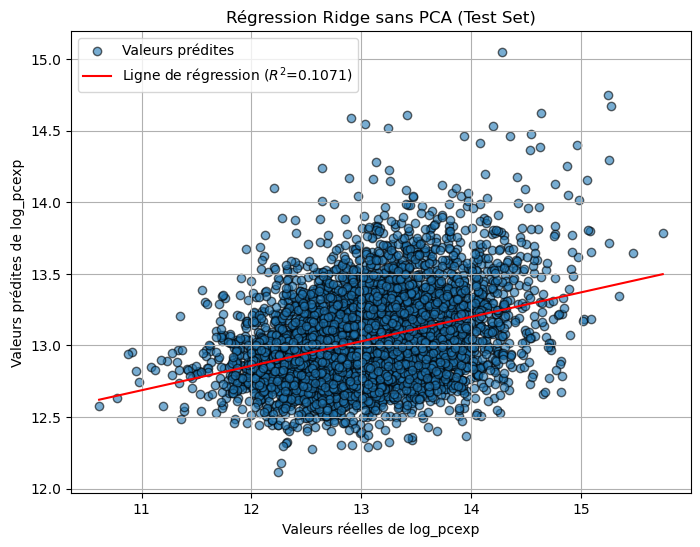

Taux de pauvreté réel : 39.0474%
Taux de pauvreté prédit (OLS PCA) : 7.4738%
Taux de pauvreté prédit (Ridge PCA) : 7.1663%
Taux de pauvreté prédit (Ridge Full) : 12.1689%


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os
import pickle

# Configuration des chemins
input_csv = r"E:\wealth_predict\data\processed_csv\DataCIV3_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16.csv"
output_dir_csv = r"E:\wealth_predict\data\processed_csv"
output_dir_models = r"E:\wealth_predict\models"
output_dir_figures = r"E:\wealth_predict\figures_graphs"

# Chargement des données
df = pd.read_csv(input_csv)
features = [f'feature_{i}' for i in range(4096)]
target = 'log_pcexp'

X = df[features]
y = df[target]

# Étape 1 : Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Étape 2.1 : PCA + OLS Regression
pca = PCA(n_components=0.9)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
num_pca_components = X_train_pca.shape[1]

print(f"Nombre de composantes principales expliquant 90% de la variabilité : {num_pca_components}")

ols_model = LinearRegression()
ols_model.fit(X_train_pca, y_train)

y_train_pred_ols = ols_model.predict(X_train_pca)
y_test_pred_ols = ols_model.predict(X_test_pca)

r2_train_ols = r2_score(y_train, y_train_pred_ols)
r2_test_ols = r2_score(y_test, y_test_pred_ols)

print(f"R² (OLS PCA) - Train: {r2_train_ols:.4f}, Test: {r2_test_ols:.4f}")

# Graphique OLS
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_ols, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y_test), np.poly1d(np.polyfit(y_test, y_test_pred_ols, 1))(np.unique(y_test)), 'r-', label=f"Ligne de régression ($R^2$={r2_test_ols:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title("Régression OLS avec PCA (Test Set)")
plt.legend()
plt.grid(True)
fig_ols_path = os.path.join(output_dir_figures, "fullyConv_sans_augm_couche_nongelee_batch_16_ols_pca_regression.png")
plt.savefig(fig_ols_path)
plt.show()

# Étape 2.2 : PCA + Ridge Regression
ridge_params = {'alpha': np.logspace(-3, 3, 50)}
ridge_model = Ridge()
grid_search_ridge_pca = GridSearchCV(ridge_model, ridge_params, scoring='r2', cv=5)
grid_search_ridge_pca.fit(X_train_pca, y_train)
best_ridge_pca = grid_search_ridge_pca.best_estimator_
best_alpha_ridge_pca = grid_search_ridge_pca.best_params_['alpha']

y_train_pred_ridge_pca = best_ridge_pca.predict(X_train_pca)
y_test_pred_ridge_pca = best_ridge_pca.predict(X_test_pca)

r2_train_ridge_pca = r2_score(y_train, y_train_pred_ridge_pca)
r2_test_ridge_pca = r2_score(y_test, y_test_pred_ridge_pca)

print(f"R² (Ridge PCA) - Train: {r2_train_ridge_pca:.4f}, Test: {r2_test_ridge_pca:.4f}, Alpha: {best_alpha_ridge_pca}")

# Graphique Ridge PCA
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_ridge_pca, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y_test), np.poly1d(np.polyfit(y_test, y_test_pred_ridge_pca, 1))(np.unique(y_test)), 'r-', label=f"Ligne de régression ($R^2$={r2_test_ridge_pca:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title("Régression Ridge avec PCA (Test Set)")
plt.legend()
plt.grid(True)
fig_ridge_pca_path = os.path.join(output_dir_figures, "fullyConv_sans_augm_couche_nongelee_batch_16_ridge_pca_regression.png")
plt.savefig(fig_ridge_pca_path)
plt.show()

# Étape 2.3 : Ridge sans PCA
grid_search_ridge_full = GridSearchCV(ridge_model, ridge_params, scoring='r2', cv=5)
grid_search_ridge_full.fit(X_train_scaled, y_train)
best_ridge_full = grid_search_ridge_full.best_estimator_
best_alpha_ridge_full = grid_search_ridge_full.best_params_['alpha']

y_train_pred_ridge_full = best_ridge_full.predict(X_train_scaled)
y_test_pred_ridge_full = best_ridge_full.predict(X_test_scaled)

r2_train_ridge_full = r2_score(y_train, y_train_pred_ridge_full)
r2_test_ridge_full = r2_score(y_test, y_test_pred_ridge_full)

print(f"R² (Ridge Full) - Train: {r2_train_ridge_full:.4f}, Test: {r2_test_ridge_full:.4f}, Alpha: {best_alpha_ridge_full}")

# Graphique Ridge Full
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_ridge_full, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y_test), np.poly1d(np.polyfit(y_test, y_test_pred_ridge_full, 1))(np.unique(y_test)), 'r-', label=f"Ligne de régression ($R^2$={r2_test_ridge_full:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title("Régression Ridge sans PCA (Test Set)")
plt.legend()
plt.grid(True)
fig_ridge_full_path = os.path.join(output_dir_figures, "fullyConv_sans_augm_couche_nongelee_batch_16_ridge_full_regression.png")
plt.savefig(fig_ridge_full_path)
plt.show()

# Étape 3 : Ajout des prédictions
df_test = df.loc[X_test.index]
df_test['log_pcexp_pred_ols_pca'] = y_test_pred_ols
df_test['log_pcexp_pred_ridge_pca'] = y_test_pred_ridge_pca
df_test['log_pcexp_pred_ridge_full'] = y_test_pred_ridge_full

test_predictions_combined_path = os.path.join(output_dir_csv, "fullyConv_sans_augm_couche_nongelee_batch_16_test_with_predictions.csv")
df_test.to_csv(test_predictions_combined_path, index=False)

# Étape 4 : Calcul du taux de pauvreté
poverty_threshold = np.log(345520)

df_test['poverty_real'] = (df_test['log_pcexp'] < poverty_threshold).astype(int)
weighted_real_poverty = (
    (df_test['hhweight'] * df_test['hhsize'] * df_test['poverty_real']).sum() /
    (df_test['hhweight'] * df_test['hhsize']).sum()
)

poverty_predictions = {}
for case, pred_col in {
    "OLS PCA": "log_pcexp_pred_ols_pca",
    "Ridge PCA": "log_pcexp_pred_ridge_pca",
    "Ridge Full": "log_pcexp_pred_ridge_full"
}.items():
    df_test[f'poverty_pred_{case.replace(" ", "_")}'] = (df_test[pred_col] < poverty_threshold).astype(int)
    weighted_poverty = (
        (df_test['hhweight'] * df_test['hhsize'] * df_test[f'poverty_pred_{case.replace(" ", "_")}']).sum() /
        (df_test['hhweight'] * df_test['hhsize']).sum()
    )
    poverty_predictions[case] = weighted_poverty

# Résultats
print(f"Taux de pauvreté réel : {weighted_real_poverty:.4%}")
for case, poverty_rate in poverty_predictions.items():
    print(f"Taux de pauvreté prédit ({case}) : {poverty_rate:.4%}")

# Sauvegarde finale
final_path = os.path.join(output_dir_csv, "fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty.csv")
df_test.to_csv(final_path, index=False)


#### Avec k-fold Cross Validation

Ce script implémente une approche complète pour prédire une variable continue (log_pcexp) en utilisant des modèles de régression et une validation croisée k-fold (paramétrable). 
1.Chargement et prétraitement des données
Le script commence par charger un fichier CSV contenant les caractéristiques (feature_0 à feature_4095) et la cible (log_pcexp). Il standardise ces données à l’aide de StandardScaler pour s’assurer que toutes les variables ont une échelle comparable, ce qui est particulièrement important pour la réduction dimensionnelle et les modèles de régression.
Étape 1 : Réduction de dimension avec PCA
Le script applique une Analyse en Composantes Principales (PCA) pour réduire la dimensionnalité tout en conservant 95 % de la variabilité totale des données. Le nombre de composantes principales retenues est affiché, montrant combien de dimensions sont nécessaires pour expliquer la majorité de la variance.
Étape 2 : Modélisation et validation croisée
Trois types de modèles de régression sont appliqués :

2.1. PCA + Régression OLS
Les composantes principales issues du PCA sont utilisées comme variables d’entrée dans une régression linéaire simple.
Une validation croisée k-fold (paramétrable) est réalisée pour obtenir les prédictions.
Le coefficient de détermination R^2 est calculé et imprimé. Un graphique est généré pour visualiser les valeurs prédites par rapport aux valeurs réelles avec une ligne de régression ajustée.
Le modèle final est sauvegardé avec un nom dynamique indiquant k-fold cross-validation.
2.2. PCA + Régression Ridge
Le modèle Ridge est utilisé sur les composantes principales. Une recherche des hyperparamètres est réalisée pour trouver la meilleure valeur d’alpha (λ).
Les prédictions sont obtenues avec validation croisée, et R^2 ainsi que l’alpha optimal sont affichés.
Un graphique similaire à celui d’OLS est tracé et sauvegardé.
Le modèle Ridge final avec PCA est sauvegardé.
2.3. Régression Ridge sans PCA
Le modèle Ridge est appliqué directement sur les données standardisées (sans réduction de dimension).
Comme précédemment, une recherche des hyperparamètres est réalisée, et R^2 ainsi que l’alpha optimal sont affichés.
Les prédictions sont visualisées avec un graphique et sauvegardées. Le modèle final est sauvegardé.

Étape 3 : Ajout des prédictions
Les prédictions de chaque modèle (OLS PCA, Ridge PCA, et Ridge Full) sont ajoutées au DataFrame d’origine dans de nouvelles colonnes, permettant une comparaison directe avec les valeurs réelles de log_pcexp.
Étape 4 : Calcul des taux de pauvreté
Le script calcule le taux de pauvreté réel et prédit en utilisant un seuil logarithmique basé sur log(345520).
Ces taux sont pondérés par hhweight et hhsize pour refléter l’impact réel de chaque observation. Les résultats suivants sont affichés :
-Le taux de pauvreté réel, basé sur les valeurs de log_pcexp.
-Les taux de pauvreté prédits pour chaque modèle (OLS PCA, Ridge PCA, Ridge Full).

Sauvegarde des résultats
-Graphiques : Chaque modèle génère un graphique visualisant les prédictions par rapport aux valeurs réelles, sauvegardé avec des noms dynamiques incluant k-fold cross-validation.
-Modèles : Tous les modèles sont sauvegardés au format pickle avec des noms explicites incluant k-fold cross-validation.
-CSV enrichi : Le DataFrame final, incluant les prédictions et les taux de pauvreté, est sauvegardé sous un nom dynamique indiquant k-fold cross-validation.


Nombre de composantes principales expliquant 90% de la variabilité : 121
R² (OLS PCA avec 5-fold cross-validation) : 0.1444


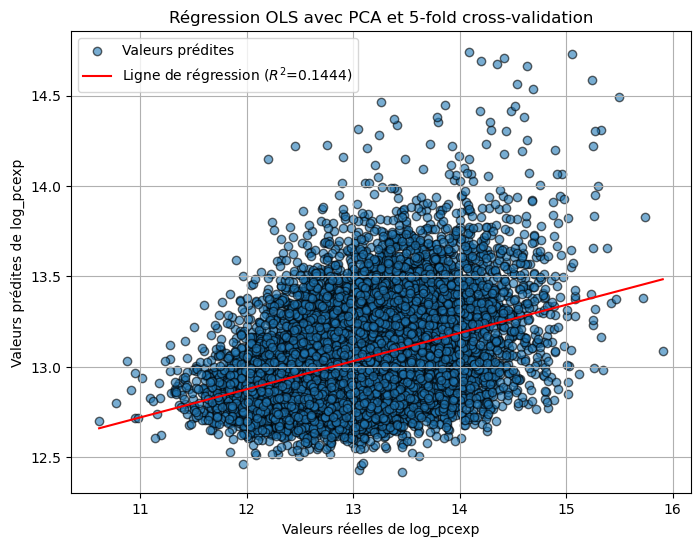

R² (Ridge PCA avec 5-fold cross-validation) : 0.1449, Alpha optimal : 1000.0


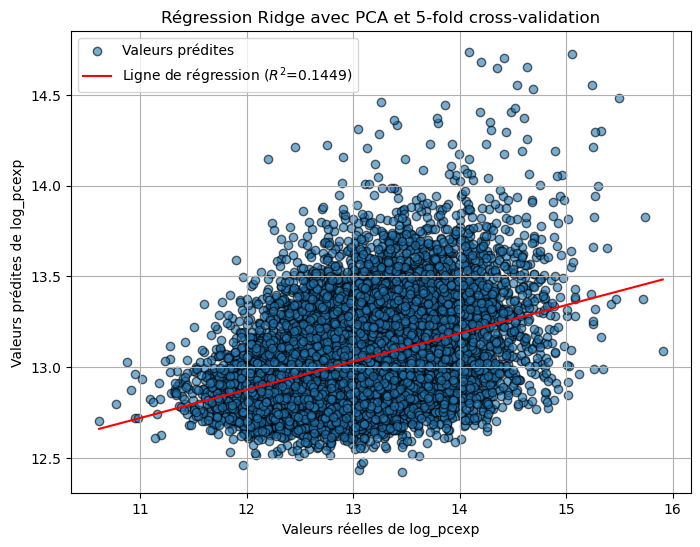

R² (Ridge sans PCA avec 5-fold cross-validation) : 0.1233, Alpha optimal : 1000.0


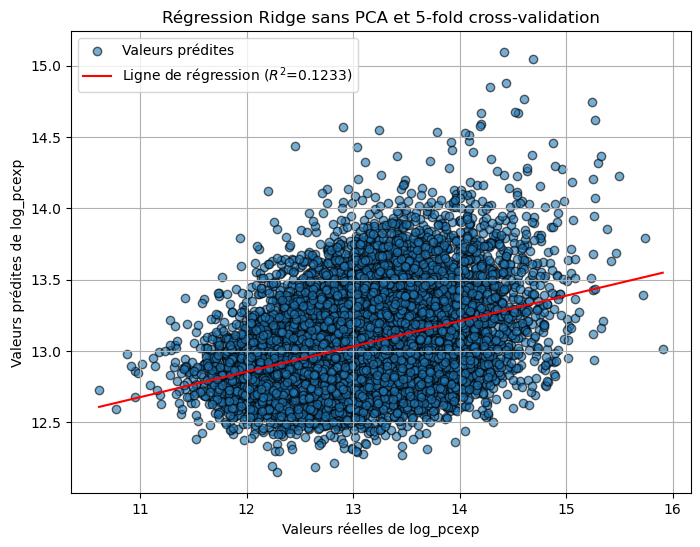

Taux de pauvreté réel : 39.4405%
Taux de pauvreté prédit (OLS PCA) : 6.7016%
Taux de pauvreté prédit (Ridge PCA) : 6.5785%
Taux de pauvreté prédit (Ridge Full) : 12.1675%


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os
import pickle

# Configuration des chemins
input_csv = r"E:\wealth_predict\data\processed_csv\DataCIV3_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16.csv"
output_dir_csv = r"E:\wealth_predict\data\processed_csv"
output_dir_models = r"E:\wealth_predict\models"
output_dir_figures = r"E:\wealth_predict\figures_graphs"

# Chargement des données
df = pd.read_csv(input_csv)
features = [f'feature_{i}' for i in range(4096)]
target = 'log_pcexp'

X = df[features]
y = df[target]

# Paramètres
k = 5  # Nombre de folds pour la cross-validation

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Étape 2.1 : PCA + OLS Regression
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)
num_pca_components = X_pca.shape[1]

print(f"Nombre de composantes principales expliquant 90% de la variabilité : {num_pca_components}")

ols_model = LinearRegression()
kf = KFold(n_splits=k, shuffle=True, random_state=42)
y_pred_ols = cross_val_predict(ols_model, X_pca, y, cv=kf)
ols_model.fit(X_pca, y)

r2_ols = r2_score(y, y_pred_ols)
print(f"R² (OLS PCA avec {k}-fold cross-validation) : {r2_ols:.4f}")

# Graphique OLS
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_ols, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y), np.poly1d(np.polyfit(y, y_pred_ols, 1))(np.unique(y)), 'r-', label=f"Ligne de régression ($R^2$={r2_ols:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title(f"Régression OLS avec PCA et {k}-fold cross-validation")
plt.legend()
plt.grid(True)
fig_ols_path = os.path.join(output_dir_figures, f"fullyConv_sans_augm_couche_nongelee_batch_16_ols_pca_{k}-fold_cross_validation.png")
plt.savefig(fig_ols_path)
plt.show()

# Sauvegarde du modèle OLS
ols_model_path = os.path.join(output_dir_models, f"fullyConv_sans_augm_couche_nongelee_batch_16_ols_pca_{k}-fold_cross_validation.pkl")
with open(ols_model_path, 'wb') as file:
    pickle.dump(ols_model, file)

# Étape 2.2 : PCA + Ridge Regression
ridge_params = {'alpha': np.logspace(-3, 3, 50)}
best_alpha_ridge_pca = None
best_r2_ridge_pca = -np.inf

for alpha in ridge_params['alpha']:
    ridge_model = Ridge(alpha=alpha)
    y_pred_ridge_pca = cross_val_predict(ridge_model, X_pca, y, cv=kf)
    r2_ridge_pca = r2_score(y, y_pred_ridge_pca)
    if r2_ridge_pca > best_r2_ridge_pca:
        best_r2_ridge_pca = r2_ridge_pca
        best_alpha_ridge_pca = alpha

ridge_model_pca = Ridge(alpha=best_alpha_ridge_pca)
ridge_model_pca.fit(X_pca, y)

print(f"R² (Ridge PCA avec {k}-fold cross-validation) : {best_r2_ridge_pca:.4f}, Alpha optimal : {best_alpha_ridge_pca}")

# Graphique Ridge PCA
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_ridge_pca, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y), np.poly1d(np.polyfit(y, y_pred_ridge_pca, 1))(np.unique(y)), 'r-', label=f"Ligne de régression ($R^2$={best_r2_ridge_pca:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title(f"Régression Ridge avec PCA et {k}-fold cross-validation")
plt.legend()
plt.grid(True)
fig_ridge_pca_path = os.path.join(output_dir_figures, f"fullyConv_sans_augm_couche_nongelee_batch_16_ridge_pca_{k}-fold_cross_validation.png")
plt.savefig(fig_ridge_pca_path)
plt.show()

# Sauvegarde du modèle Ridge PCA
ridge_pca_model_path = os.path.join(output_dir_models, f"fullyConv_sans_augm_couche_nongelee_batch_16_ridge_pca_{k}-fold_cross_validation.pkl")
with open(ridge_pca_model_path, 'wb') as file:
    pickle.dump(ridge_model_pca, file)

# Étape 2.3 : Ridge sans PCA
best_alpha_ridge_full = None
best_r2_ridge_full = -np.inf

for alpha in ridge_params['alpha']:
    ridge_model = Ridge(alpha=alpha)
    y_pred_ridge_full = cross_val_predict(ridge_model, X_scaled, y, cv=kf)
    r2_ridge_full = r2_score(y, y_pred_ridge_full)
    if r2_ridge_full > best_r2_ridge_full:
        best_r2_ridge_full = r2_ridge_full
        best_alpha_ridge_full = alpha

ridge_model_full = Ridge(alpha=best_alpha_ridge_full)
ridge_model_full.fit(X_scaled, y)

print(f"R² (Ridge sans PCA avec {k}-fold cross-validation) : {best_r2_ridge_full:.4f}, Alpha optimal : {best_alpha_ridge_full}")

# Graphique Ridge Full
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_ridge_full, alpha=0.6, label="Valeurs prédites", edgecolor='k')
plt.plot(np.unique(y), np.poly1d(np.polyfit(y, y_pred_ridge_full, 1))(np.unique(y)), 'r-', label=f"Ligne de régression ($R^2$={best_r2_ridge_full:.4f})")
plt.xlabel("Valeurs réelles de log_pcexp")
plt.ylabel("Valeurs prédites de log_pcexp")
plt.title(f"Régression Ridge sans PCA et {k}-fold cross-validation")
plt.legend()
plt.grid(True)
fig_ridge_full_path = os.path.join(output_dir_figures, f"fullyConv_sans_augm_couche_nongelee_batch_16_ridge_full_{k}-fold_cross_validation.png")
plt.savefig(fig_ridge_full_path)
plt.show()

# Sauvegarde du modèle Ridge Full
ridge_full_model_path = os.path.join(output_dir_models, f"fullyConv_sans_augm_couche_nongelee_batch_16_ridge_full_{k}-fold_cross_validation.pkl")
with open(ridge_full_model_path, 'wb') as file:
    pickle.dump(ridge_model_full, file)

# Étape 3 : Ajout des prédictions dans le DataFrame
df['log_pcexp_pred_ols_pca'] = y_pred_ols
df['log_pcexp_pred_ridge_pca'] = y_pred_ridge_pca
df['log_pcexp_pred_ridge_full'] = y_pred_ridge_full

# Étape 4 : Calcul du taux de pauvreté
poverty_threshold = np.log(345520)
df['poverty_real'] = (df['log_pcexp'] < poverty_threshold).astype(int)

weighted_real_poverty = (
    (df['hhweight'] * df['hhsize'] * df['poverty_real']).sum() /
    (df['hhweight'] * df['hhsize']).sum()
)

poverty_predictions = {}
for case, pred_col in {
    "OLS PCA": "log_pcexp_pred_ols_pca",
    "Ridge PCA": "log_pcexp_pred_ridge_pca",
    "Ridge Full": "log_pcexp_pred_ridge_full"
}.items():
    df[f'poverty_pred_{case.replace(" ", "_")}'] = (df[pred_col] < poverty_threshold).astype(int)
    weighted_poverty = (
        (df['hhweight'] * df['hhsize'] * df[f'poverty_pred_{case.replace(" ", "_")}']).sum() /
        (df['hhweight'] * df['hhsize']).sum()
    )
    poverty_predictions[case] = weighted_poverty

# Impression des résultats
print(f"Taux de pauvreté réel : {weighted_real_poverty:.4%}")
for case, poverty_rate in poverty_predictions.items():
    print(f"Taux de pauvreté prédit ({case}) : {poverty_rate:.4%}")

# Sauvegarde finale
final_path = os.path.join(output_dir_csv, f"fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_{k}-fold_cross_validation.csv")
df.to_csv(final_path, index=False)
